# 5G Tower Optimizer — Data Exploration (EDA)
Covers: data loading, quality checks, population heatmap, building distribution, spatial alignment.

In [1]:
import sys, os

# Fix path — works whether you launch from project root or notebooks folder
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shapely.geometry import Point

from data_pipeline.preprocessing.validate import DataValidator
from data_pipeline.preprocessing.normalize import get_bounds

plt.rcParams['figure.figsize'] = (12, 5)
print('Imports OK ✔')

Imports OK ✔


## 1. Load data

In [2]:
cities = ['peshawar', 'karachi', 'lahore', 'islamabad']
pop_gdfs = {}
bldg_gdfs = {}

for city in cities:
    pop_path  = os.path.join(project_root, 'data_pipeline', 'sample_data', f'{city}_test_population.csv')
    bldg_path = os.path.join(project_root, 'data_pipeline', 'sample_data', f'{city}_test_buildings.geojson')
    if os.path.exists(pop_path) and os.path.exists(bldg_path):
        df = pd.read_csv(pop_path)
        pop_gdfs[city] = gpd.GeoDataFrame(
            df,
            geometry=[Point(r.longitude, r.latitude) for r in df.itertuples()],
            crs='EPSG:4326'
        )
        bldg_gdfs[city] = gpd.read_file(bldg_path)
        print(f'{city.title():12s}: {len(pop_gdfs[city]):>5} pop points | {len(bldg_gdfs[city]):>5} buildings')
    else:
        print(f'{city.title():12s}: data not found — run synthetic_city.py first')

Peshawar    :  5000 pop points |  2000 buildings
Karachi     :  5000 pop points |  2000 buildings
Lahore      :  5000 pop points |  2000 buildings
Islamabad   :  5000 pop points |  2000 buildings


## 2. Data quality checks

In [3]:
validator = DataValidator()

for city, gdf in pop_gdfs.items():
    r = validator.validate_population(gdf)
    b = validator.validate_buildings(bldg_gdfs[city])
    align = validator.check_spatial_alignment(gdf, bldg_gdfs[city])
    print(f'\n=== {city.title()} ===')
    print(f'  Population valid : {r.is_valid}  | errors: {r.errors} | warnings: {r.warnings}')
    print(f'  Buildings valid  : {b.is_valid}  | errors: {b.errors} | warnings: {b.warnings}')
    print(f'  Spatial overlap  : {align["overlap_percent"]}%')
    print(f'  Pop stats        : {r.stats}')


=== Peshawar ===
  Population valid : True  | errors: [] | warnings: []
  Buildings valid  : True  | errors: [] | warnings: []
  Spatial overlap  : 65.61%
  Pop stats        : {'total_points': 5000, 'missing_geometry': 0, 'duplicates': 0, 'total_population': 7989208}

=== Karachi ===
  Population valid : True  | errors: [] | warnings: []
  Buildings valid  : True  | errors: [] | warnings: []
  Spatial overlap  : 75.24%
  Pop stats        : {'total_points': 5000, 'missing_geometry': 0, 'duplicates': 0, 'total_population': 7997420}

=== Lahore ===
  Population valid : True  | errors: [] | warnings: []
  Buildings valid  : True  | errors: [] | warnings: []
  Spatial overlap  : 81.66%
  Pop stats        : {'total_points': 5000, 'missing_geometry': 0, 'duplicates': 0, 'total_population': 7997420}

=== Islamabad ===
  Population valid : True  | errors: [] | warnings: []
  Buildings valid  : True  | errors: [] | warnings: []
  Spatial overlap  : 81.13%
  Pop stats        : {'total_points': 5

## 3. Population distribution per city

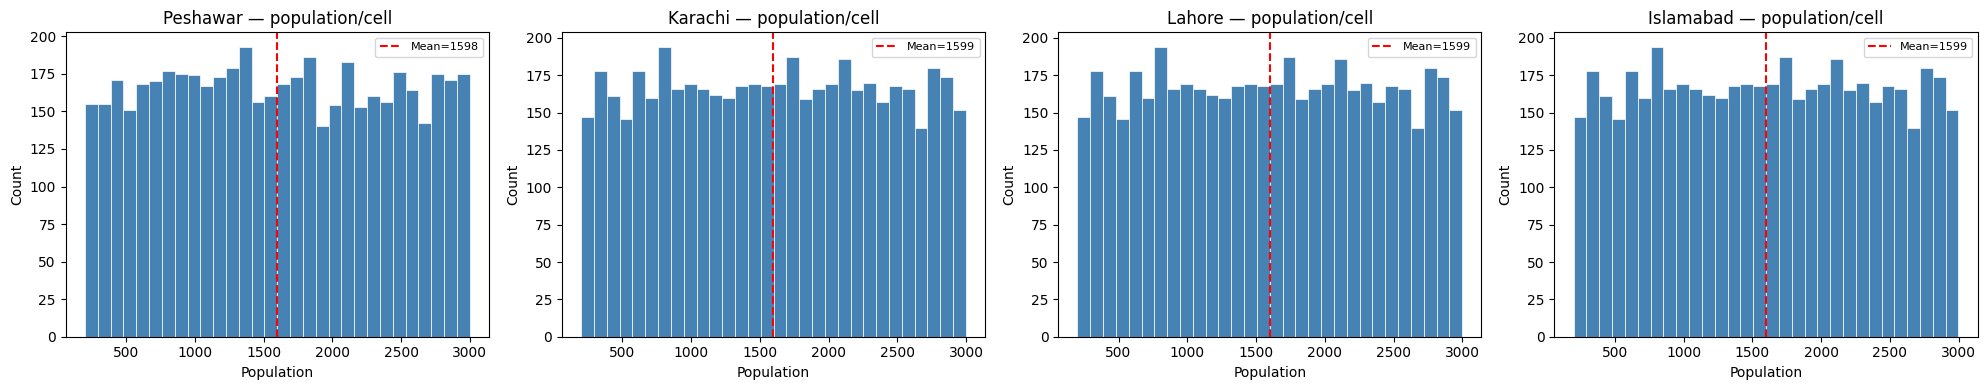

In [4]:
fig, axes = plt.subplots(1, len(pop_gdfs), figsize=(5 * len(pop_gdfs), 4))
if len(pop_gdfs) == 1:
    axes = [axes]

for ax, (city, gdf) in zip(axes, pop_gdfs.items()):
    ax.hist(gdf['population'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(f'{city.title()} — population/cell')
    ax.set_xlabel('Population')
    ax.set_ylabel('Count')
    ax.axvline(gdf['population'].mean(), color='red', linestyle='--', label=f'Mean={gdf["population"].mean():.0f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Population density heatmap (scatter)

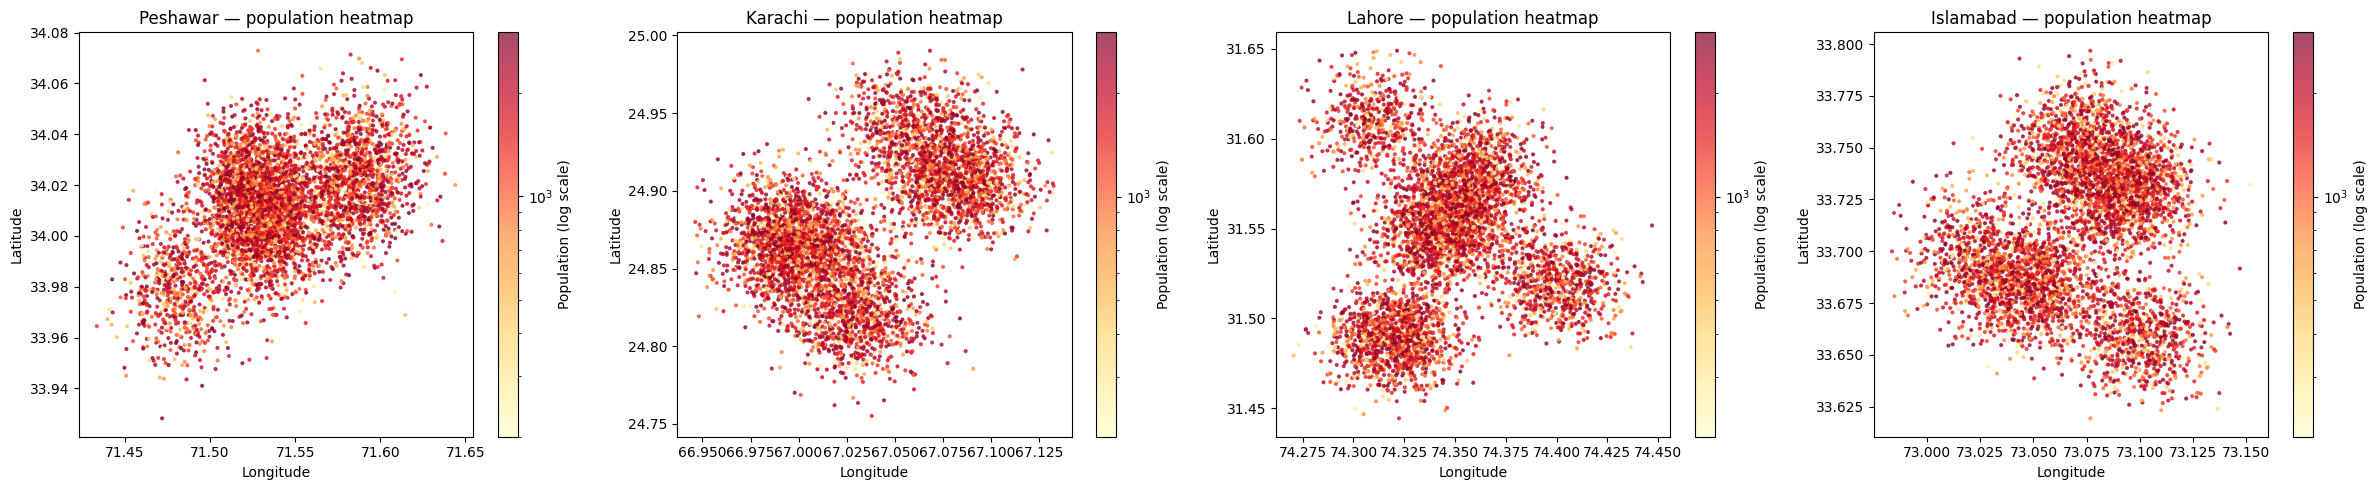

In [5]:
fig, axes = plt.subplots(1, len(pop_gdfs), figsize=(6 * len(pop_gdfs), 5))
if len(pop_gdfs) == 1:
    axes = [axes]

for ax, (city, gdf) in zip(axes, pop_gdfs.items()):
    sc = ax.scatter(
        gdf.geometry.x, gdf.geometry.y,
        c=gdf['population'], cmap='YlOrRd', s=4, alpha=0.7,
        norm=mcolors.LogNorm(vmin=max(1, gdf['population'].min()), vmax=gdf['population'].max())
    )
    plt.colorbar(sc, ax=ax, label='Population (log scale)')
    ax.set_title(f'{city.title()} — population heatmap')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

## 5. Building type distribution

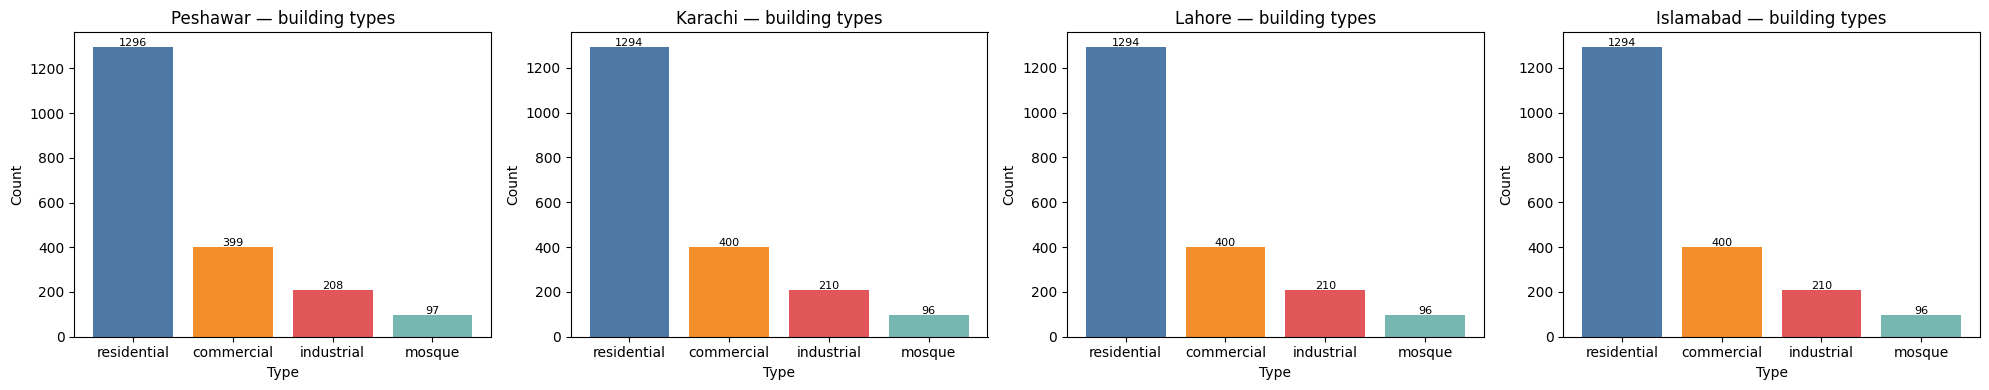

In [6]:
fig, axes = plt.subplots(1, len(bldg_gdfs), figsize=(5 * len(bldg_gdfs), 4))
if len(bldg_gdfs) == 1:
    axes = [axes]

for ax, (city, gdf) in zip(axes, bldg_gdfs.items()):
    col = 'building' if 'building' in gdf.columns else gdf.columns[0]
    counts = gdf[col].value_counts()
    ax.bar(counts.index, counts.values, color=['#4e79a7','#f28e2b','#e15759','#76b7b2'][:len(counts)])
    ax.set_title(f'{city.title()} — building types')
    ax.set_xlabel('Type')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Outlier / data quality summary

#### summary_rows = []
for city, gdf in pop_gdfs.items():
    pop = gdf['population']
    q99 = pop.quantile(0.99)
    outliers = (pop > q99).sum()
    summary_rows.append({
        'City': city.title(),
        'Points': len(gdf),
        'Total Pop': f"{pop.sum():,}",
        'Mean': f"{pop.mean():.0f}",
        'Max': f"{pop.max():,}",
        'Nulls': gdf['population'].isna().sum(),
        'Outliers (>P99)': outliers,
    })

pd.DataFrame(summary_rows).set_index('City')